In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
import matplotlib.pyplot as plt
import numpy as np

In [2]:
class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        # C1 - Convolution layer (in_channels, out_channels, kernel_size)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1, padding=2)
        # S2 - Subsampling layer
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)
        # C3 - Convolution layer
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1)
        # S4 - Subsampling layer
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        # C5 - Fully connected layer
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        # F6 - Fully connected layer
        self.fc2 = nn.Linear(120, 84)
        # Output layer
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))    # Apply ReLU on C1
        x = self.pool1(x)            # Apply S2 (pooling)
        x = F.relu(self.conv2(x))    # Apply ReLU on C3
        x = self.pool2(x)            # Apply S4 (pooling)
        x = x.view(-1, 16 * 5 * 5)   # Flatten the output from conv layers
        x = F.relu(self.fc1(x))      # Apply ReLU on C5
        x = F.relu(self.fc2(x))      # Apply ReLU on F6
        x = self.fc3(x)              # Output layer
        return x

In [3]:
device = 'cpu'

# 实例化模型
model = LeNet5().to(device)
image = torch.randn(20000,1,28,28).to(device)

start_time1 = time.time()
out = model(image)
end_time1 = time.time()

cpu_time = end_time1 - start_time1

device = 'cuda'

model = model.to(device)
image = image.to(device)


start_time2 = time.time()
out = model(image)
end_time2 = time.time()
gpu_time = end_time2 - start_time2

print(f'device cpu cost time :{cpu_time}s')
print(f'device gpu cost time :{gpu_time}s')
print(f'gpu is quickly than cpu at the rate :{int(cpu_time/gpu_time)}')

device cpu cost time :0.4284236431121826s
device gpu cost time :0.24891328811645508s
gpu is quickly than cpu at the rate :1


In [4]:
print(model)

LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [5]:
def plot_loss(losses):
    
    plt.plot(range(len(losses)),losses)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# 定义适合 CIFAR-10 的 AlexNet 模型
class AlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1), # CIFAR-10 用 3x3 卷积核
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        
        # 修改全连接层，适应 32x32 CIFAR-10 数据
        self.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(256 * 4 * 4, 1024),  # CIFAR-10 的输入调整为 1024 隐藏单元
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.classifier(x)
        return x

# CIFAR-10 数据集的预处理
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# 加载 CIFAR-10 数据集
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=100, shuffle=False, num_workers=2)


Files already downloaded and verified
Files already downloaded and verified
Epoch 1/10, Loss: 2.1787
Epoch 2/10, Loss: 1.7714


KeyboardInterrupt: 

In [ ]:
# 实例化模型、定义损失函数和优化器
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AlexNet(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

# 训练模型
def train_model(model, trainloader, criterion, optimizer, epochs=1):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(trainloader):.4f}")

# 测试模型
def test_model(model, testloader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    print(f"Test Accuracy: {100 * correct / total:.2f}%")

# 执行训练和测试
train_model(model, trainloader, criterion, optimizer, epochs=10)
test_model(model, testloader)

Files already downloaded and verified
Files already downloaded and verified


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


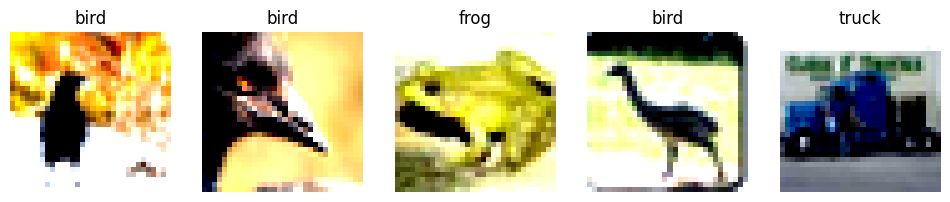

In [13]:
transform = transforms.Compose([
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])



trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=100, shuffle=False, num_workers=2)
# CIFAR-10 类别标签
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# 定义一个函数，将张量图像转换为可视化的格式
def imshow(img):
    img = img / 2 + 0.5  # 将归一化的图片还原
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# 从 trainloader 中获取一批数据
dataiter = iter(trainloader)
images, labels = next(dataiter)

# 随机展示 5 张图片
fig, axes = plt.subplots(1, 5, figsize=(12, 2.5))
for i in range(5):
    idx = np.random.randint(0, len(images))  # 随机选择一个索引
    ax = axes[i]
    ax.imshow(np.transpose(images[idx].numpy() / 2 + 0.5, (1, 2, 0)))  # 将图像还原并显示
    ax.set_title(classes[labels[idx].item()])
    ax.axis('off')

plt.show()

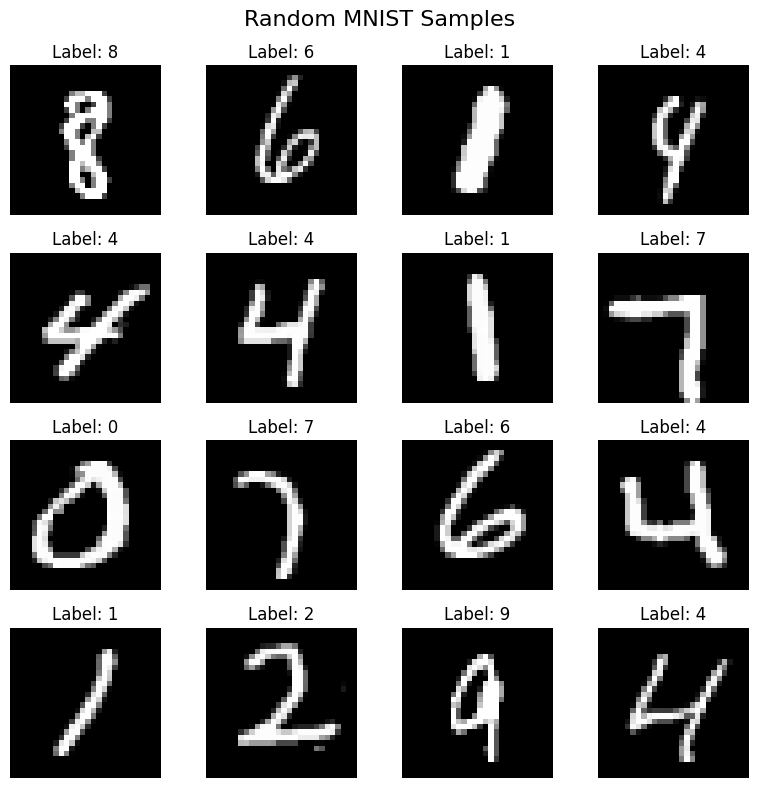

In [2]:
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np

# 定义数据预处理
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST 数据集的均值和标准差
])

# 加载 MNIST 数据集
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)

# 从数据加载器中获取一批数据
dataiter = iter(trainloader)
images, labels = next(dataiter)

# 将图像数据转换为 numpy 格式，以便可视化
images = images.numpy()

# 可视化前 16 个样本
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
fig.suptitle("Random MNIST Samples", fontsize=16)
for i, ax in enumerate(axes.flat):
    # 展示灰度图像，调整通道为单通道 (1, 28, 28)
    ax.imshow(images[i][0], cmap='gray')
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis('off')  # 隐藏坐标轴

plt.tight_layout()
plt.show()
